In [34]:
words = open('names.txt').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [35]:
print(len(words), min(len(w) for w in words), max(len(w) for w in words))

32033 2 15


In [36]:
b = {}
for w in words:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1
sorted(b.items(), key=lambda item: -item[1])
len(b.items())

627

In [37]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [38]:
import torch
# 28 is 26 alphabets + 2 for <S> and <E>
N = torch.zeros((27, 27), dtype=torch.float32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        N[idx1, idx2] += 1
N.shape

torch.Size([27, 27])

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

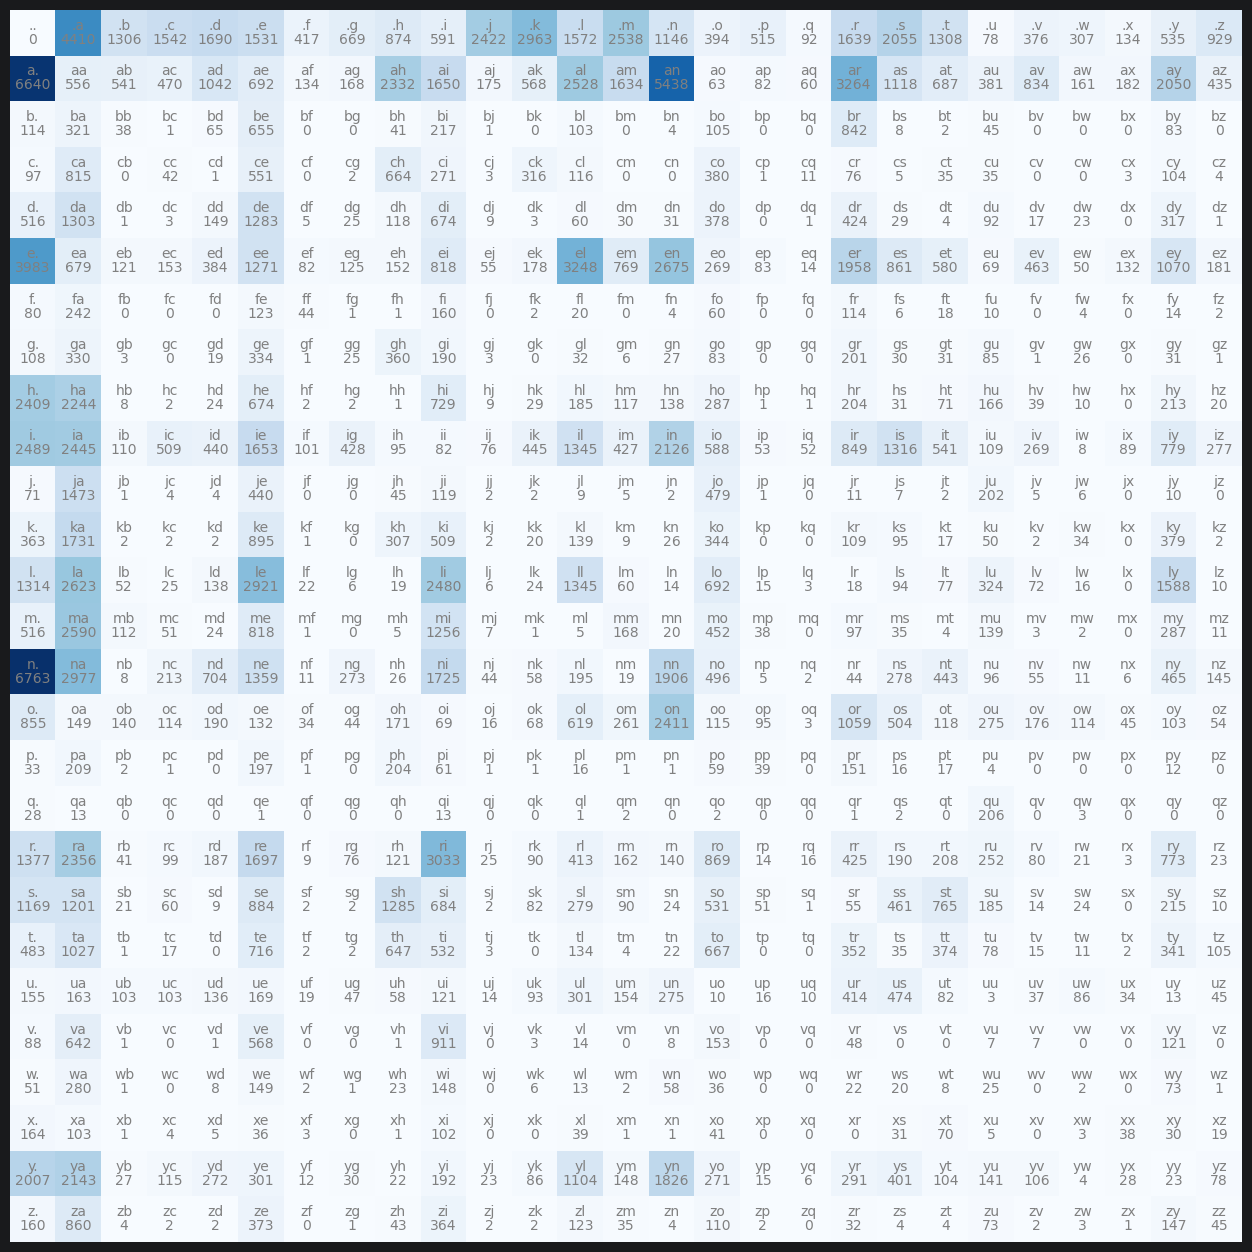

In [39]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, int(N[i,j].item()), ha='center', va='top', color='gray')
plt.axis('off')

In [40]:
P = (N+1).float()
K1 = P.sum(dim=1)
K2 = P.sum(dim=1, keepdim=True)
# P.shape, K1, K1.shape, K2, K2.shape
P /= P.sum(dim=1, keepdim=True)
sum(P[0])


tensor(1.0000)

In [41]:
g  = torch.Generator().manual_seed(2147483647)
idx = torch.multinomial(P[0], num_samples=1000, replacement=True, generator=g).tolist()
torch.argmax(P[0])


tensor(1)

In [42]:
g  = torch.Generator().manual_seed(2147483647)

for i in range(20):
    idx = 0
    out = []
    while True:
        p = P[idx]
        idx = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()

        # samples = torch.multinomial(p, num_samples=100, replacement=True, generator=g)
        # counts = torch.bincount(samples, minlength=len(p))
        # idx = int(torch.argmax(counts))

        nextChar = itos[idx]
        out.append(nextChar)
        if nextChar == '.':
            break
        idx = stoi[nextChar]

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.


In [43]:
log_likelihood = 0.0
n = 0
for w in ["zhengyuanjq"]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        prob = P[idx1, idx2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n += 1
        # print(f'{ch1}{ch2}:{ prob}', f'log_prob:{log_prob}')

print(f'log_likelihood:{log_likelihood}')
nll = -log_likelihood
print(f'nll:{nll/n}')


log_likelihood:-45.676151275634766
nll:3.8063459396362305


In [45]:
xs = []
ys = []
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        idx1 = stoi[ch1]
        idx2 = stoi[ch2]
        print(f'{ch1}{ch2}:{ idx1},{idx2}')
        xs.append(idx1)
        ys.append(idx2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)

.e:0,5
em:5,13
mm:13,13
ma:13,1
a.:1,0


In [46]:
xs

tensor([ 0,  5, 13, 13,  1])

In [47]:
ys

tensor([ 5, 13, 13,  1,  0])

In [48]:
import torch.nn.functional as F
F.one_hot(xs, num_classes=27)

tensor([[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0]])